In [1]:
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.lines import Line2D
from scipy.stats import pearsonr, gaussian_kde
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from unpack_lmer_res import get_single_unit_prediction_params

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
## load the data

datasets = {
    'onset': {},
    'peakrate': {},
    'duration': {}
}

model = 1
for key in datasets.keys():

    summary_data = {}

    data_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'data_1.csv')
    summary_data[f'data_{model}'] = pd.read_csv(data_path).drop(columns = 'Unnamed: 0')


    unitwise_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', f'm1_{key}_unitwise_params.csv')
    summary_data[f'm{model}_unitwise_params'] = pd.read_csv(unitwise_path).drop(columns = 'Unnamed: 0')


    fixef_path = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', f'm1_{key}_fixed_effects.csv') 
    summary_data[f'm{model}_fixed_effects'] = pd.read_csv(fixef_path).rename(
        columns = {f'fixef(model_{model})':'fixef', 'Unnamed: 0': 'name'}
    )

    prediction_params = {}
    prediction_params[f'model_{model}'] = {
        'brain_area': [],
        'sign': [],
        'intercept_u': [],
        'intercept_e': [],
        'slope_u': [],
        'slope_e': [],
    }

    summary_data[f'm{model}_unitwise_params'].apply(
        get_single_unit_prediction_params, 
        model = model, 
        summary_data = summary_data, 
        prediction_params = prediction_params,
        axis = 1
    )

    prediction_params[f'model_{model}'] = pd.DataFrame(prediction_params[f'model_{model}'])
    prediction_params[f'model_{model}']['unit'] = [x[0] for x in summary_data[f'data_{model}'].groupby(['unit', 'sign']).agg(list).index.values]
    prediction_params[f'model_{model}'] = prediction_params[f'model_{model}'][
    [    'brain_area', 'unit', 'sign',
        'intercept_u', 'intercept_e',
        'slope_u', 'slope_e']
    ]

    del summary_data
    datasets[key] = prediction_params
    del prediction_params

In [4]:
## Get the V1 units that uniquely load onto PC1 and PC2

v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_pca = pd.read_pickle(v1_xs_file)
pc1_loadings = np.abs(v1_pca.components.mean(0)[0])
pc2_loadings = np.abs(v1_pca.components.mean(0)[1])

pc1_sorted_indices = np.argsort(np.abs(v1_pca.components.mean(0)[0]))[::-1]
pc2_sorted_indices = np.argsort(np.abs(v1_pca.components.mean(0)[1]))[::-1]
union = []
pc1si = []
pc2si = []
for i in range(259):
    if (pc1_sorted_indices[i]) not in union:
        pc1si.append(pc1_sorted_indices[i])
        union.append(pc1_sorted_indices[i])

    if (pc2_sorted_indices[i]) not in union:
        pc2si.append(pc2_sorted_indices[i])
        union.append(pc2_sorted_indices[i])

## Inhibition delay in V1 (Difference of enhancement vs suppression onset intercept)

In [5]:
v1_suppression_intercepts = datasets['onset'][f'model_{model}'].loc[
    ( datasets['onset'][f'model_{model}'].brain_area =='v1')
    & ( datasets['onset'][f'model_{model}'].sign == 'suppression')
].intercept_u.values

v1_enhancement_intercepts =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['onset'][f'model_{model}'].brain_area =='v1')
    & ( datasets['onset'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

v1_suppression_delays = v1_suppression_intercepts - v1_enhancement_intercepts

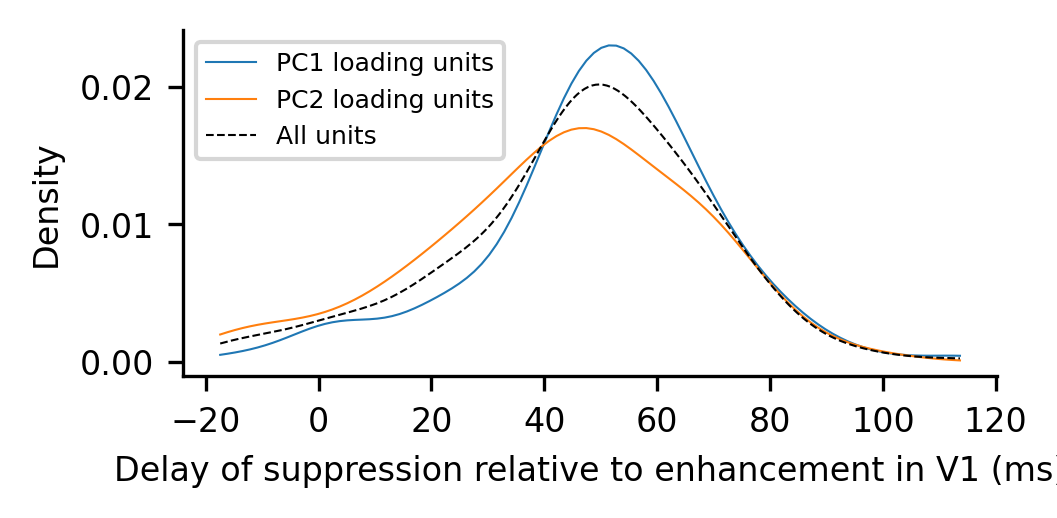

In [6]:
fig, ax = plt.subplots(figsize = (3.5,1.5))
labels = ['PC1 loading units', 'PC2 loading units']
for i, pc_group in enumerate([pc1si, pc2si]):
    x = np.linspace(
        v1_suppression_delays.min(),
        v1_suppression_delays.max(),
        100
    )

    kde = gaussian_kde(v1_suppression_delays[pc_group])
    y = kde(x)
    ax.plot(x,y, label = labels[i], linewidth = linewidth)

x = np.linspace(
    v1_suppression_delays.min(),
    v1_suppression_delays.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(v1_suppression_delays)
y = kde(x)
ax.plot(x,y, '--', label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = 6)
ax.set_xlabel("Delay of suppression relative to enhancement in V1 (ms)", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## V1 inhibition weight (V1 peak firing rate intercept)

In [7]:
v1_suppression_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'suppression')
].intercept_u.values

v1_enhancement_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values

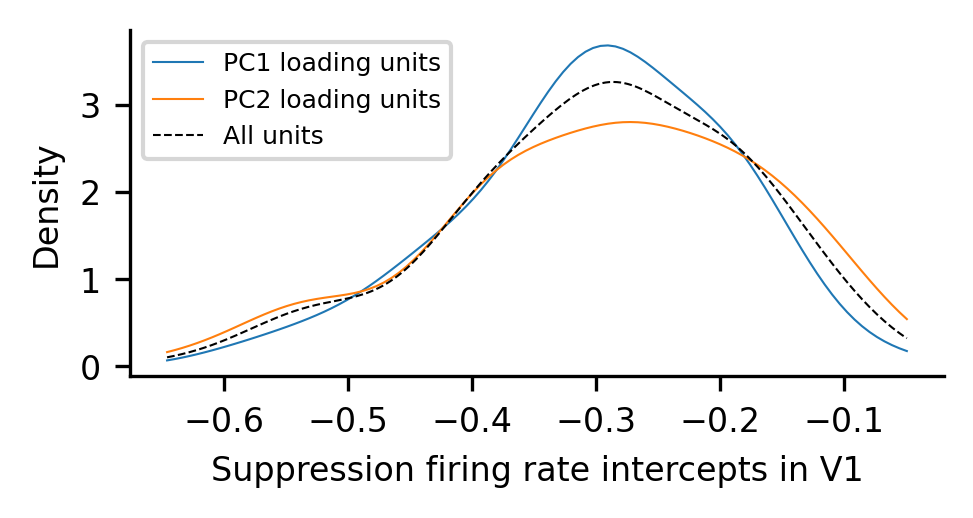

In [8]:
fig, ax = plt.subplots(figsize = (3.5,1.5))
labels = ['PC1 loading units', 'PC2 loading units']
for i, pc_group in enumerate([pc1si, pc2si]):
    x = np.linspace(
        v1_suppression_peakrate_intercepts.min(),
        v1_suppression_peakrate_intercepts.max(),
        100
    )

    kde = gaussian_kde(v1_suppression_peakrate_intercepts[pc_group])
    y = kde(x)
    ax.plot(x,y, label = labels[i], linewidth = linewidth)

x = np.linspace(
    v1_suppression_peakrate_intercepts.min(),
    v1_suppression_peakrate_intercepts.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(v1_suppression_peakrate_intercepts)
y = kde(x)
ax.plot(x,y, '--', label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = 6)
ax.set_xlabel("Suppression firing rate intercepts in V1", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

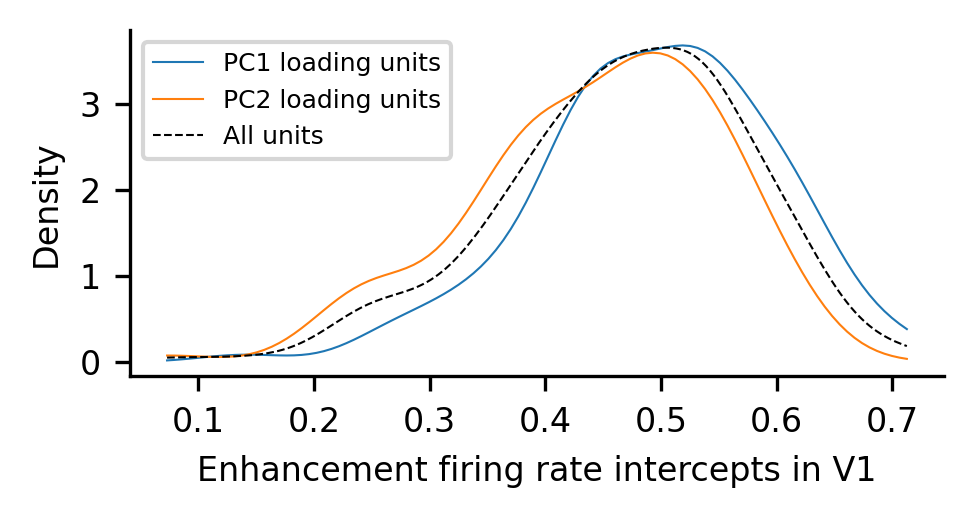

In [9]:
fig, ax = plt.subplots(figsize = (3.5,1.5))
labels = ['PC1 loading units', 'PC2 loading units']
for i, pc_group in enumerate([pc1si, pc2si]):
    x = np.linspace(
        v1_enhancement_peakrate_intercepts.min(),
        v1_enhancement_peakrate_intercepts.max(),
        100
    )

    kde = gaussian_kde(v1_enhancement_peakrate_intercepts[pc_group])
    y = kde(x)
    ax.plot(x,y, label = labels[i], linewidth = linewidth)

x = np.linspace(
    v1_enhancement_peakrate_intercepts.min(),
    v1_enhancement_peakrate_intercepts.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(v1_enhancement_peakrate_intercepts)
y = kde(x)
ax.plot(x,y, '--', label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = 6)
ax.set_xlabel("Enhancement firing rate intercepts in V1", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## dLGN frequency-time slope (dLGN enhancement onset slopes)

In [10]:
dlgn_onset_slopes =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].slope_u.values


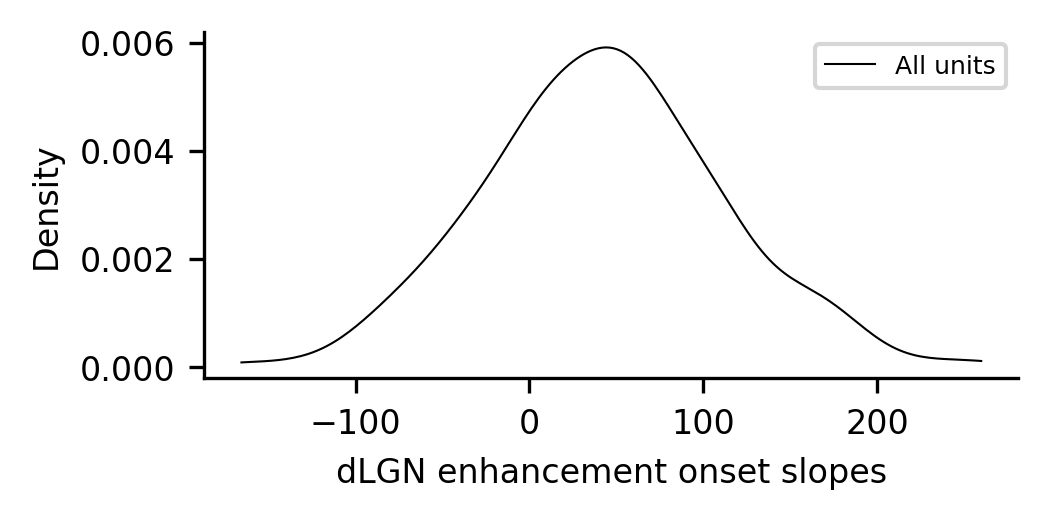

In [11]:
fig, ax = plt.subplots(figsize = (3.5,1.5))

x = np.linspace(
    dlgn_onset_slopes.min(),
    dlgn_onset_slopes.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(dlgn_onset_slopes)
y = kde(x)
ax.plot(x,y, label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = 6)
ax.set_xlabel("dLGN enhancement onset slopes", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## dLGN onset time (dLGN enhancement onset intercepts)

In [12]:
dlgn_onset_intercepts =  datasets['onset'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


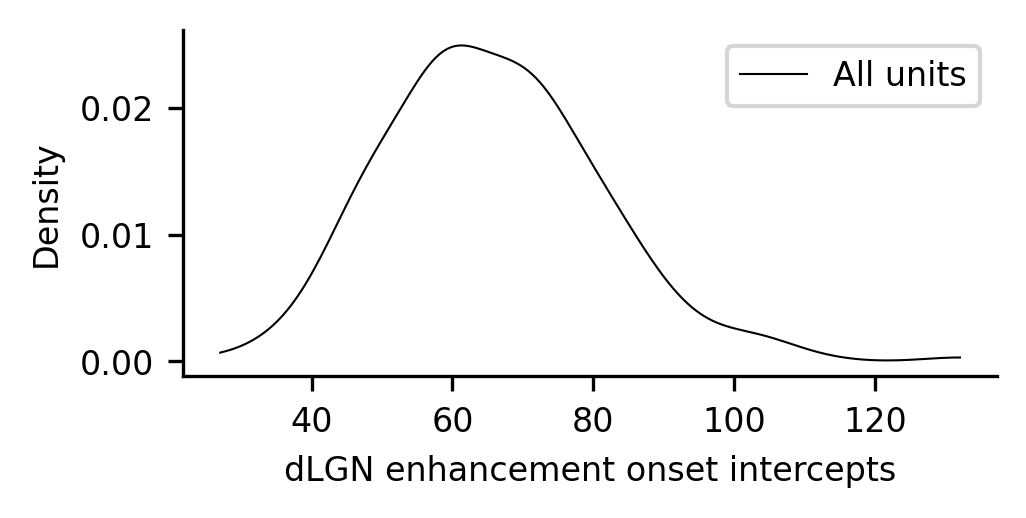

In [13]:
fig, ax = plt.subplots(figsize = (3.5,1.5))

x = np.linspace(
    dlgn_onset_intercepts.min(),
    dlgn_onset_intercepts.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(dlgn_onset_intercepts)
y = kde(x)
ax.plot(x,y, label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = fontsize)
ax.set_xlabel("dLGN enhancement onset intercepts", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## dLGN frequency-amplitude slope (dLGN peak firing rate slopes)

In [14]:
dlgn_peakrate_slopes =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].slope_u.values


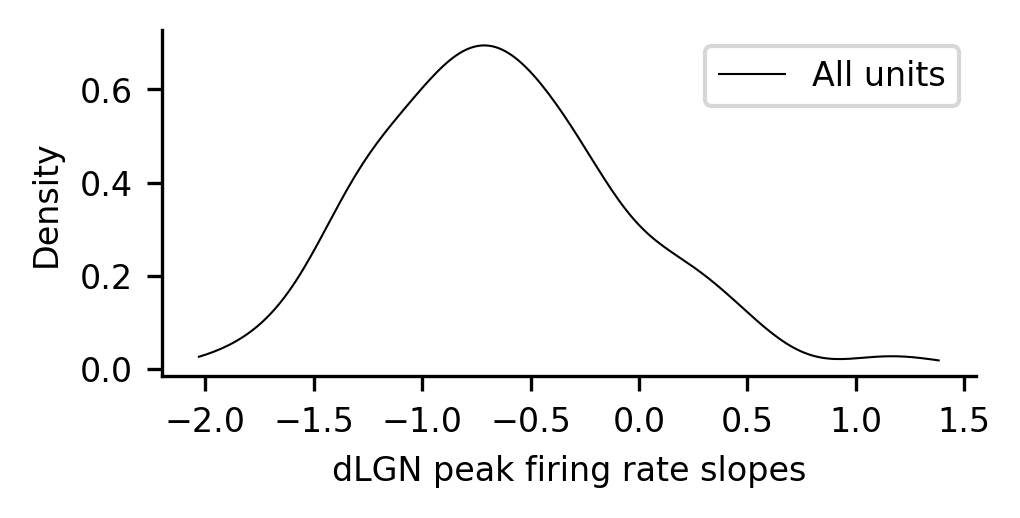

In [15]:
fig, ax = plt.subplots(figsize = (3.5,1.5))

x = np.linspace(
    dlgn_peakrate_slopes.min(),
    dlgn_peakrate_slopes.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(dlgn_peakrate_slopes)
y = kde(x)
ax.plot(x,y, label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = fontsize)
ax.set_xlabel("dLGN peak firing rate slopes", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## dLGN amplitude (dLGN peak firing rate intercept)

In [16]:
dlgn_peakrate_intercepts =  datasets['peakrate'][f'model_{model}'].loc[
    ( datasets['peakrate'][f'model_{model}'].brain_area =='v1')
    & ( datasets['peakrate'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


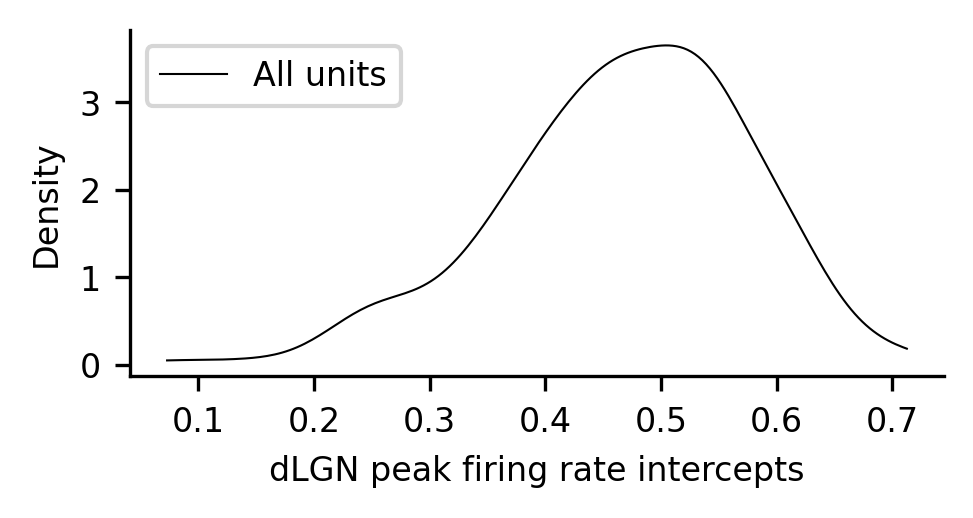

In [17]:
fig, ax = plt.subplots(figsize = (3.5,1.5))

x = np.linspace(
    dlgn_peakrate_intercepts.min(),
    dlgn_peakrate_intercepts.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(dlgn_peakrate_intercepts)
y = kde(x)
ax.plot(x,y, label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = fontsize)
ax.set_xlabel("dLGN peak firing rate intercepts", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()

## dLGN response duration (dLGN response duration intercept)

In [18]:
dlgn_duration_intercepts =  datasets['duration'][f'model_{model}'].loc[
    ( datasets['duration'][f'model_{model}'].brain_area =='v1')
    & ( datasets['duration'][f'model_{model}'].sign == 'enhancement')
].intercept_u.values


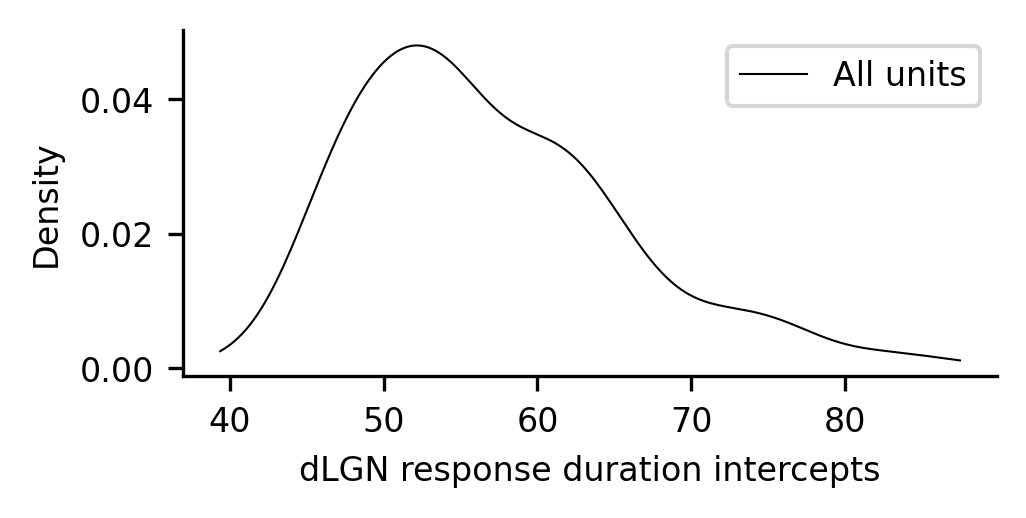

In [19]:
fig, ax = plt.subplots(figsize = (3.5,1.5))

x = np.linspace(
    dlgn_duration_intercepts.min(),
    dlgn_duration_intercepts.max(),
    200
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize = fontsize)

kde = gaussian_kde(dlgn_duration_intercepts)
y = kde(x)
ax.plot(x,y, label = 'All units', color = 'black', linewidth = linewidth)

ax.legend(fontsize = fontsize)
ax.set_xlabel("dLGN response duration intercepts", fontsize = fontsize)
ax.set_ylabel("Density", fontsize = fontsize)
plt.show()